In [35]:
from google.colab import drive
drive.mount('/content/gdrive')
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
!ls /content/gdrive/MyDrive/'Colab Notebooks'/'HOPE AI'/'Week6-Data_Science-Bivariate/Assignment'

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
DS_assign.ipynb			   Placement_Data_Full_Class.csv
Placement_Assignment_Answers.docx


In [36]:
dataset = pd.read_csv("/content/gdrive/MyDrive/Colab Notebooks/HOPE AI/Week6-Data_Science-Bivariate/Assignment/Placement_Data_Full_Class.csv")
dataset.isnull().sum()

,0
sl_no,2
gender,2
ssc_p,2
ssc_b,2
hsc_p,2
hsc_b,2
hsc_s,2
degree_p,2
degree_t,2
workex,2


In [37]:
#Removing sl.no no required
dataset.drop('sl_no',inplace=True,axis=1)
dataset.isnull().sum()

,0
gender,2
ssc_p,2
ssc_b,2
hsc_p,2
hsc_b,2
hsc_s,2
degree_p,2
degree_t,2
workex,2
etest_p,2


In [38]:
# Remove rows where status is missing
dataset = dataset.dropna(subset=['status'])
#q1
# Replace salary missing values with 0
dataset['salary'] = dataset['salary'].fillna(0)

In [39]:
dataset.isnull().sum()

,0
gender,0
ssc_p,0
ssc_b,0
hsc_p,0
hsc_b,0
hsc_s,0
degree_p,0
degree_t,0
workex,0
etest_p,0


In [40]:
#q2
#finding placed or not using status column
dataset['status'].value_counts()

,count
status,
Placed,148
Not Placed,67


In [41]:
dataset.describe()

,ssc_p,hsc_p,degree_p,etest_p,mba_p,salary
count,215.000000,215.000000,215.000000,215.000000,215.000000,215.000000
mean,67.303395,66.333163,66.370186,72.100558,62.278186,198702.325581
std,10.827205,10.897509,7.358743,13.275956,5.833385,154780.926716
min,40.890000,37.000000,50.000000,50.000000,51.210000,0.000000
25%,60.600000,60.900000,61.000000,60.000000,57.945000,0.000000
50%,67.000000,65.000000,66.000000,71.000000,62.000000,240000.000000
75%,75.700000,73.000000,72.000000,83.500000,66.255000,282500.000000
max,89.400000,97.700000,91.000000,98.000000,77.890000,940000.000000


In [42]:
def quanQual(dataset):
    quan=[]
    qual=[]
    for columnName in dataset.columns:
        #print(columnName)
        if(dataset[columnName].dtype=='O'):
            #print("qual")
            qual.append(columnName)
        else:
            #print("quan")
            quan.append(columnName)
    return quan,qual

In [43]:
quan,qaul=quanQual(dataset)

In [44]:
dataset[quan]

,ssc_p,hsc_p,degree_p,etest_p,mba_p,salary
0,67.00,91.00,58.00,55.0,58.80,270000.0
1,79.33,78.33,77.48,86.5,66.28,200000.0
2,65.00,68.00,64.00,75.0,57.80,250000.0
3,56.00,52.00,52.00,66.0,59.43,0.0
4,85.80,73.60,73.30,96.8,55.50,425000.0
...,...,...,...,...,...,...
212,80.60,82.00,77.60,91.0,74.49,400000.0
213,58.00,60.00,72.00,74.0,53.62,275000.0
214,67.00,67.00,73.00,59.0,69.72,295000.0
215,74.00,66.00,58.00,70.0,60.23,204000.0


In [45]:
import numpy as np
descriptive=pd.DataFrame(index=["Mean","Median","Mode","Q1:25%","Q2:50%",
                               "Q3:75%","99%","Q4:100%","IQR","1.5rule","Lesser","Greater","Min","Max"],columns=quan)
for columnName in quan:
    descriptive[columnName]["Mean"]=dataset[columnName].mean()
    descriptive[columnName]["Median"]=dataset[columnName].median()
    descriptive[columnName]["Mode"]=dataset[columnName].mode()[0]
    descriptive[columnName]["Q1:25%"]=dataset.describe()[columnName]["25%"]
    descriptive[columnName]["Q2:50%"]=dataset.describe()[columnName]["50%"]
    descriptive[columnName]["Q3:75%"]=dataset.describe()[columnName]["75%"]
    descriptive[columnName]["99%"]=np.percentile(dataset[columnName],99)
    descriptive[columnName]["Q4:100%"]=dataset.describe()[columnName]["max"]
    descriptive[columnName]["IQR"]=descriptive[columnName]["Q3:75%"]-descriptive[columnName]["Q1:25%"]
    descriptive[columnName]["1.5rule"]=1.5*descriptive[columnName]["IQR"]
    descriptive[columnName]["Lesser"]=descriptive[columnName]["Q1:25%"]-descriptive[columnName]["1.5rule"]
    descriptive[columnName]["Greater"]=descriptive[columnName]["Q3:75%"]+descriptive[columnName]["1.5rule"]
    descriptive[columnName]["Min"]=dataset[columnName].min()
    descriptive[columnName]["Max"]=dataset[columnName].max()

In [46]:
descriptive

,ssc_p,hsc_p,degree_p,etest_p,mba_p,salary
Mean,67.303395,66.333163,66.370186,72.100558,62.278186,198702.325581
Median,67.0,65.0,66.0,71.0,62.0,240000.0
Mode,62.0,63.0,65.0,60.0,56.7,0.0
Q1:25%,60.6,60.9,61.0,60.0,57.945,0.0
Q2:50%,67.0,65.0,66.0,71.0,62.0,240000.0
Q3:75%,75.7,73.0,72.0,83.5,66.255,282500.0
99%,87.0,91.86,83.86,97.0,76.1142,629000.0
Q4:100%,89.4,97.7,91.0,98.0,77.89,940000.0
IQR,15.1,12.1,11.0,23.5,8.31,282500.0
1.5rule,22.65,18.15,16.5,35.25,12.465,423750.0


In [47]:
dataset[['salary','mba_p']].corr()

,salary,mba_p
salary,1.000000,0.139823
mba_p,0.139823,1.000000


In [48]:
#q6
(dataset['salary'] > 500000).sum()

np.int64(3)

In [49]:
#q3
dataset.groupby('status')[[
    'ssc_p',
    'hsc_p',
    'degree_p',
    'etest_p',
    'mba_p'
]].mean()

,ssc_p,hsc_p,degree_p,etest_p,mba_p
status,,,,,
Not Placed,57.544030,58.395522,61.134179,69.587910,61.612836
Placed,71.721486,69.926554,68.740541,73.238041,62.579392


In [50]:
#q4
dataset[['salary','mba_p']].corr()

,salary,mba_p
salary,1.000000,0.139823
mba_p,0.139823,1.000000


In [51]:
#q5
dataset.groupby('specialisation')['salary'].mean()

,salary
specialisation,
Mkt&Fin,236591.666667
Mkt&HR,150842.105263


In [52]:
#q7
from scipy.stats import f_oneway

f_stat,p_value = f_oneway(
    dataset['etest_p'],
    dataset['mba_p']
)

print(f_stat)
print(p_value)

98.64487057324709
4.672547689133573e-21


In [53]:
#q8
from scipy.stats import f_oneway
from scipy.stats import ttest_ind
from scipy.stats import norm
from scipy.stats import zscore

import matplotlib.pyplot as plt
import seaborn as sns

salary_scitech = dataset[
    dataset['degree_t']=='Sci&Tech'
]['salary']

salary_hr = dataset[
    dataset['specialisation']=='Mkt&HR'
]['salary']

t_stat,p_value = ttest_ind(
    salary_scitech,
    salary_hr
)

print("T Statistic =",t_stat)
print("P Value =",p_value)

if p_value < 0.05:
    print("Reject Null Hypothesis")
else:
    print("Accept Null Hypothesis")

T Statistic = 2.692041243555374
P Value = 0.007897969943471179
Reject Null Hypothesis


In [54]:
#q9
dataset['salary_zscore'] = zscore(
    dataset['salary']
)

print(dataset[
    ['salary','salary_zscore']
].head())


     salary  salary_zscore
0  270000.0       0.461711
1  200000.0       0.008404
2  250000.0       0.332195
3       0.0      -1.286761
4  425000.0       1.465463


In [55]:
#q10
mean_salary = dataset['salary'].mean()

std_salary = dataset['salary'].std()

probability = (
    norm.cdf(
        900000,
        mean_salary,
        std_salary
    )
    -
    norm.cdf(
        700000,
        mean_salary,
        std_salary
    )
)

print("Probability =",probability)



Probability = 0.0005973243061798694


In [56]:
#q11
scitech = dataset[
    dataset['degree_t']=='Sci&Tech'
]

f_stat,p_value = f_oneway(
    scitech['etest_p'],
    scitech['mba_p']
)

print("F Statistic =",f_stat)
print("P Value =",p_value)

if p_value < 0.05:
    print("Reject ANONA Null Hypothesis")
else:
    print("Accept ANON Null Hypothesis")

F Statistic = 20.53902604077106
P Value = 1.4289217003775155e-05
Reject ANONA Null Hypothesis


In [57]:
#q12
correlation_matrix = dataset.corr(
    numeric_only=True
)

salary_corr = correlation_matrix[
    'salary'
].sort_values(
    ascending=False
)

print(salary_corr)

salary           1.000000
salary_zscore    1.000000
ssc_p            0.538090
hsc_p            0.452569
degree_p         0.408371
etest_p          0.186988
mba_p            0.139823
Name: salary, dtype: float64


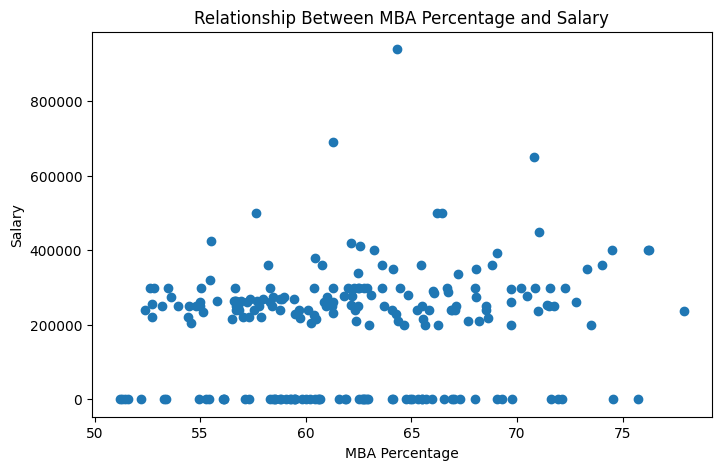

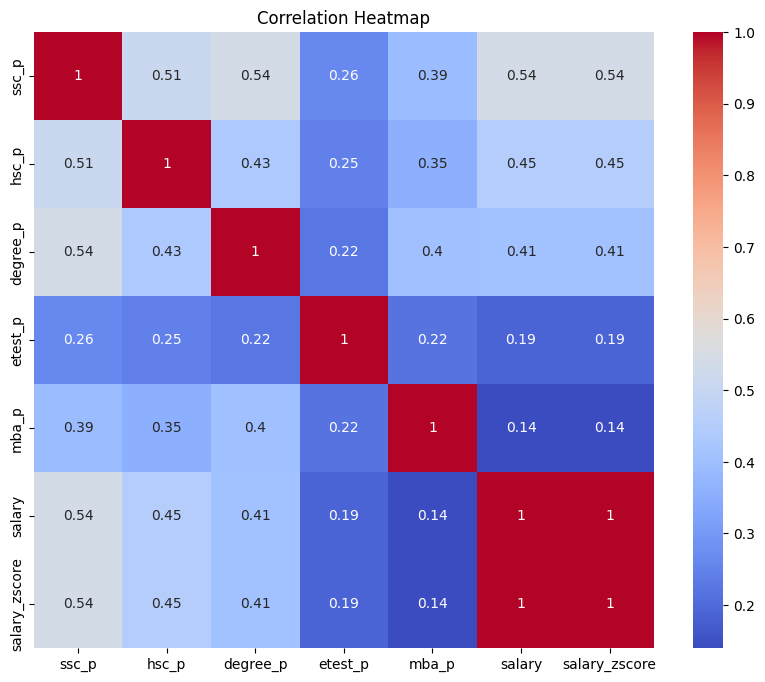

In [58]:
#q13

plt.figure(figsize=(8,5))

plt.scatter(
    dataset['mba_p'],
    dataset['salary']
)

plt.xlabel("MBA Percentage")

plt.ylabel("Salary")

plt.title(
    "Relationship Between MBA Percentage and Salary"
)

plt.show()

# Map

plt.figure(figsize=(10,8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()